<div style="font-size:22pt; line-height:25pt; font-weight:bold; text-align:center;">SAC for V2G</div>

This notebook trains a Soft Actor-Critic (SAC) policy on the V2G environment, then visualises the learnt behaviour.

## 1 · Environment

In [1]:
from ev2gym.models.ev2gym_env import EV2Gym
from ev2gym.rl_agent.state import V2G_profit_max
from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np
import matplotlib.pyplot as plt

env = EV2Gym(
    config_file="custom.yaml",
    save_replay=False,
    save_plots=False,
    state_function=V2G_profit_max,
)
env = Monitor(env)
print("Observation space:", env.observation_space)
print("Action space:     ", env.action_space)

/home/emmanuel/anaconda3/lib/python3.13/site-packages/ev2gym/utilities/loaders.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Observation space: Box(-inf, inf, (42,), float64)
Action space:      Box(-1.0, 1.0, (10,), float64)


## 2 · Training callback

We log the mean episodic return from `ep_info_buffer` every 4 rollouts.

In [2]:
class ReturnTrackingCallback(BaseCallback):
    """Records mean episodic return every `freq` rollouts."""

    def __init__(self, freq=4, verbose=0):
        super().__init__(verbose)
        self.freq = freq
        self._rollout_count = 0
        self.timesteps = []
        self.returns = []

    def _on_rollout_end(self):
        self._rollout_count += 1
        if self._rollout_count % self.freq == 0 and len(self.model.ep_info_buffer) > 0:
            mean_return = np.mean([ep["r"] for ep in self.model.ep_info_buffer])
            self.timesteps.append(self.num_timesteps)
            self.returns.append(mean_return)

    def _on_step(self):
        return True

## 3 · Training

In [3]:
model = SAC("MlpPolicy", env, verbose=1)
callback = ReturnTrackingCallback(freq=4)
model.learn(total_timesteps=100_000, callback=callback)

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 80        |
|    ep_rew_mean     | -1.68e+04 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 80        |
|    time_elapsed    | 3         |
|    total_timesteps | 320       |
| train/             |           |
|    actor_loss      | 263       |
|    critic_loss     | 1.62e+05  |
|    ent_coef        | 0.937     |
|    ent_coef_loss   | -0.84     |
|    learning_rate   | 0.0003    |
|    n_updates       | 219       |
----------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 80       |
|    ep_rew_mean     | -9.9e+03 |
| time/              |          |
|    episodes        | 8        |
|    fps             | 64       |
|    time_elapsed    | 9        |
|    total_timesteps | 640      |
| train/             |          |
|    actor_lo

----------------------------------
| rollout/           |           |
|    ep_len_mean     | 80        |
|    ep_rew_mean     | -1.03e+04 |
| time/              |           |
|    episodes        | 8         |
|    fps             | 76        |
|    time_elapsed    | 8         |
|    total_timesteps | 640       |
| train/             |           |
|    actor_loss      | 336       |
|    critic_loss     | 4.21e+04  |
|    ent_coef        | 0.882     |
|    ent_coef_loss   | -0.437    |
|    learning_rate   | 0.0003    |
|    n_updates       | 539       |
----------------------------------


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 80        |
|    ep_rew_mean     | -8.73e+03 |
| time/              |           |
|    episodes        | 12        |
|    fps             | 70        |
|    time_elapsed    | 13        |
|    total_timesteps | 960       |
| train/             |           |
|    actor_loss      | 395       |
|    critic_loss     | 3.65e+04  |
|    ent_coef        | 0.88      |
|    ent_coef_loss   | 0.0375    |
|    learning_rate   | 0.0003    |
|    n_updates       | 859       |
----------------------------------


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 80        |
|    ep_rew_mean     | -8.13e+03 |
| time/              |           |
|    episodes        | 16        |
|    fps             | 65        |
|    time_elapsed    | 19        |
|    total_timesteps | 1280      |
| train/             |           |
|    actor_loss      | 513       |
|    critic_loss     | 3.32e+04  |
|    ent_coef        | 0.893     |
|    ent_coef_loss   | 0.277     |
|    learning_rate   | 0.0003    |
|    n_updates       | 1179      |
----------------------------------


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 80        |
|    ep_rew_mean     | -7.76e+03 |
| time/              |           |
|    episodes        | 20        |
|    fps             | 61        |
|    time_elapsed    | 25        |
|    total_timesteps | 1600      |
| train/             |           |
|    actor_loss      | 772       |
|    critic_loss     | 6.78e+04  |
|    ent_coef        | 0.921     |
|    ent_coef_loss   | 0.253     |
|    learning_rate   | 0.0003    |
|    n_updates       | 1499      |
----------------------------------


...

----------------------------------
| rollout/           |           |
|    ep_len_mean     | 80        |
|    ep_rew_mean     | -5.76e+03 |
| time/              |           |
|    episodes        | 108       |
|    fps             | 63        |
|    time_elapsed    | 135       |
|    total_timesteps | 8640      |
| train/             |           |
|    actor_loss      | 1.96e+03  |
|    critic_loss     | 1.91e+05  |
|    ent_coef        | 2.23      |
|    ent_coef_loss   | 0.46      |
|    learning_rate   | 0.0003    |
|    n_updates       | 8539      |
----------------------------------


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 80        |
|    ep_rew_mean     | -5.74e+03 |
| time/              |           |
|    episodes        | 112       |
|    fps             | 63        |
|    time_elapsed    | 140       |
|    total_timesteps | 8960      |
| train/             |           |
|    actor_loss      | 1.79e+03  |
|    critic_loss     | 6.33e+04  |
|    ent_coef        | 2.08      |
|    ent_coef_loss   | 0.999     |
|    learning_rate   | 0.0003    |
|    n_updates       | 8859      |
----------------------------------


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 80        |
|    ep_rew_mean     | -5.62e+03 |
| time/              |           |
|    episodes        | 116       |
|    fps             | 64        |
|    time_elapsed    | 144       |
|    total_timesteps | 9280      |
| train/             |           |
|    actor_loss      | 1.92e+03  |
|    critic_loss     | 1.28e+05  |
|    ent_coef        | 2.05      |
|    ent_coef_loss   | -0.151    |
|    learning_rate   | 0.0003    |
|    n_updates       | 9179      |
----------------------------------


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 80        |
|    ep_rew_mean     | -5.58e+03 |
| time/              |           |
|    episodes        | 120       |
|    fps             | 64        |
|    time_elapsed    | 149       |
|    total_timesteps | 9600      |
| train/             |           |
|    actor_loss      | 1.9e+03   |
|    critic_loss     | 1.39e+05  |
|    ent_coef        | 2.03      |
|    ent_coef_loss   | 0.0512    |
|    learning_rate   | 0.0003    |
|    n_updates       | 9499      |
----------------------------------


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 80        |
|    ep_rew_mean     | -5.72e+03 |
| time/              |           |
|    episodes        | 124       |
|    fps             | 64        |
|    time_elapsed    | 154       |
|    total_timesteps | 9920      |
| train/             |           |
|    actor_loss      | 2.1e+03   |
|    critic_loss     | 1.02e+05  |
|    ent_coef        | 2.04      |
|    ent_coef_loss   | -0.326    |
|    learning_rate   | 0.0003    |
|    n_updates       | 9819      |
----------------------------------


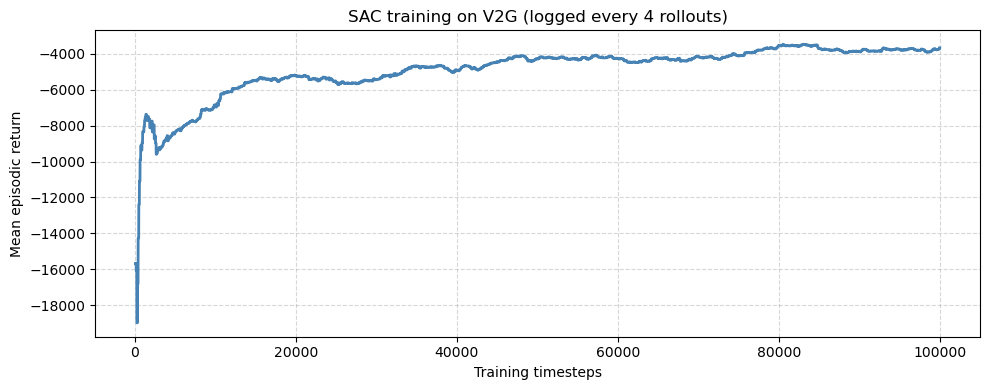

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(callback.timesteps, callback.returns, linewidth=2, color="steelblue")
ax.set_xlabel("Training timesteps")
ax.set_ylabel("Mean episodic return")
ax.set_title("SAC training on V2G (logged every 4 rollouts)")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4 · Save and reload

In [5]:
model.save("sac_v2g_model")
print("Model saved to sac_v2g_model.zip")

Model saved to sac_v2g_model.zip


In [6]:
model = SAC.load("sac_v2g_model", env=env)
print("Model loaded from sac_v2g_model.zip")

Wrapping the env in a DummyVecEnv.
Model loaded from sac_v2g_model.zip


## 5 · Rollout

In [7]:
obs, _ = env.reset()
done = False
total_reward = 0.0

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    done = terminated or truncated

print(f"Episode return: {total_reward:.1f}")

Episode return: -1739.7


## 6 · Visualisation

The left axis shows the electricity spot price; the right axis shows the total power drawn (positive) or returned (negative) at each time step, broken down by charging station using stacked vertical bars.

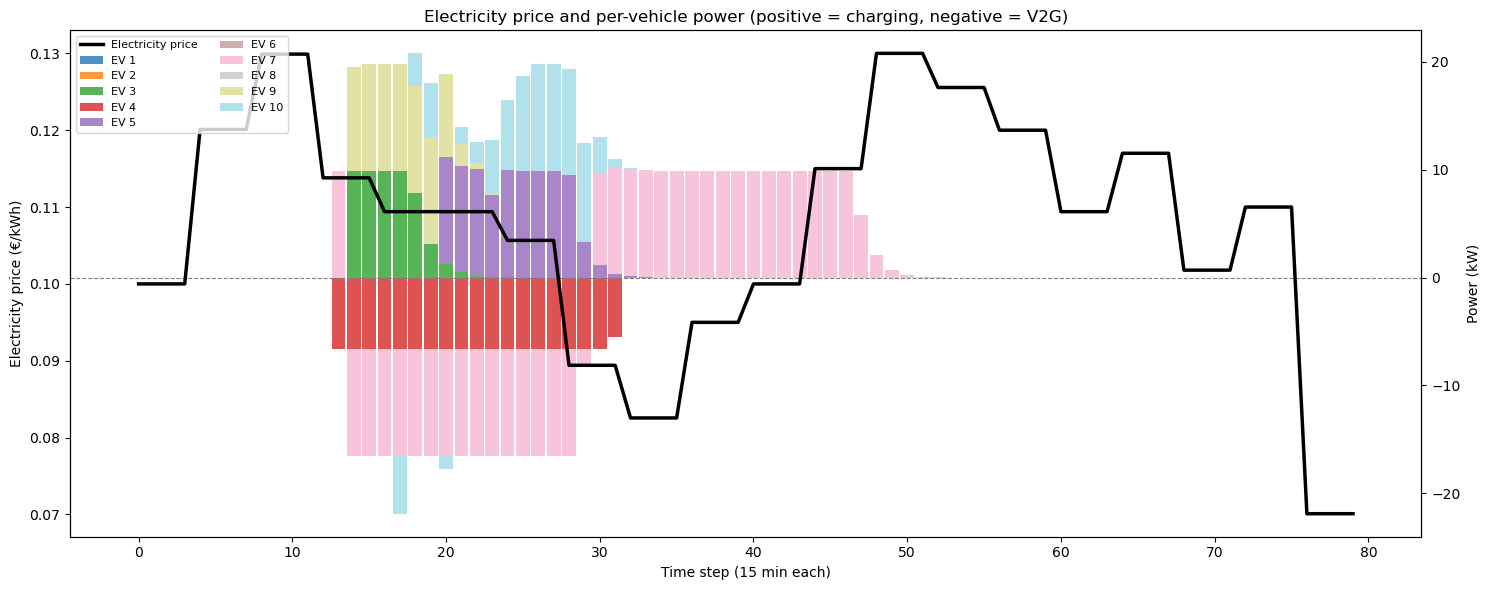

In [8]:
raw_env = env.env   # unwrap Monitor to reach EV2Gym

T    = raw_env.simulation_length
n_cs = raw_env.cs
t    = np.arange(T)

# discharge_prices are positive (EUR/kWh); identical across CS, so index [0, :]
prices   = raw_env.discharge_prices[0, :]   # shape (T,)
cs_power = raw_env.cs_power                 # shape (n_cs, T)  +ve=charge  -ve=V2G

colors = plt.cm.tab20(np.linspace(0, 1, n_cs))

fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()

# --- stacked bars: positive contributions upward, negative downward ---
pos_bottom = np.zeros(T)
neg_bottom = np.zeros(T)
for i in range(n_cs):
    power = cs_power[i, :]
    pos   = np.clip(power, 0, None)
    neg   = np.clip(power, None, 0)
    ax2.bar(t, pos, bottom=pos_bottom, color=colors[i],
            label=f"EV {i+1}", alpha=0.8, width=0.9)
    ax2.bar(t, neg, bottom=neg_bottom, color=colors[i],
            alpha=0.8, width=0.9)
    pos_bottom += pos
    neg_bottom += neg

ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Power (kW)")

# --- electricity price on top ---
ax1.plot(t, prices, color="black", linewidth=2.5, zorder=5,
         label="Electricity price")
ax1.set_xlabel("Time step (15 min each)")
ax1.set_ylabel("Electricity price (€/kWh)")
# bring price axis on top so its zero-line doesn't hide the bars
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", ncol=2, fontsize=8)

plt.title("Electricity price and per-vehicle power (positive = charging, negative = V2G)")
plt.tight_layout()
plt.show()